This version lowers the brightness threshold and uses a Morphological Closing to bridge the gaps in the cracks, making them easier for the algorithm to 'see' as single objects.

#  Old Photo Restoration
## Digital Image Processing Pipeline

---

### What this notebook does
Old photographs suffer from several types of damage over time:
- **Noise and grain** — random pixel variations caused by the analog film process or physical degradation
- **Scratches and cracks** — thin bright lines caused by physical damage to the photo surface
- **Low contrast** — fading caused by aging of the photographic paper
- **Sepia / color cast** — yellowing of the paper over decades

### Pipeline overview
```
Original Image
     │
     ▼
Step 1 — Denoising          (remove grain and noise)
     │
     ▼
Step 2 — Scratch Detection  (find damaged areas → binary mask)
     │
     ▼
Step 3 — Inpainting         (fill in the damaged areas)
     │
     ▼
Step 4 — Contrast (CLAHE)   (improve local contrast)
     │
     ▼
Step 5 — Color Correction   (fix sepia / grayscale tone)
     │
     ▼
Final Restored Image
```


---
## 1. Imports and Helper Functions

In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


def show_images(images, titles, cmap_list=None, figsize=None):
    """
    Display a row of images side by side.
    """
    n = len(images)
    if figsize is None:
        figsize = (5 * n, 5)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        cmap = None
        if cmap_list and cmap_list[titles.index(title)]:
            cmap = cmap_list[titles.index(title)]
            ax.imshow(img, cmap=cmap)
        elif len(img.shape) == 2:          # already grayscale
            ax.imshow(img, cmap='gray')
        else:                              # BGR → RGB
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=13)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

---
## 2. Load Images

Loaded C:\Users\Menna\old-photo-restoration-dip\assets\gallery_originals\img1.jpg — size: 592×784 pixels

Total images loaded: 1


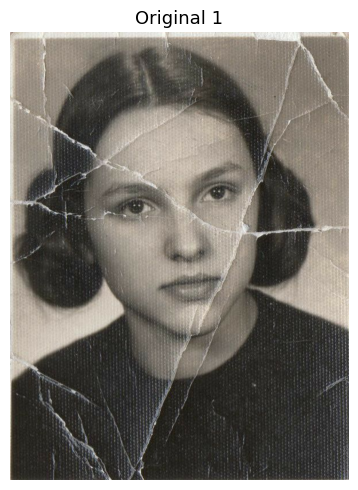

In [54]:
# ── Configuration: add or remove paths here ──────────────────────────────────
IMAGE_PATHS = [
    r"C:\Users\Menna\old-photo-restoration-dip\assets\gallery_originals\img1.jpg",
    # r"C:\Users\Zakaria\Downloads\digital_project\old-photo-restoration-dip\assets\gallery_originals\img2.jpg",
    # r"C:\Users\Zakaria\Downloads\digital_project\old-photo-restoration-dip\assets\gallery_originals\img3.jpg",
    # r"C:\Users\Zakaria\Downloads\digital_project\old-photo-restoration-dip\assets\gallery_originals\img4.jpg",
]

# Load all images
originals = []
for path in IMAGE_PATHS:
    img = cv2.imread(path)
    if img is None:
        print(f"WARNING: Could not load {path}")
    else:
        originals.append(img)
        print(f"Loaded {path} — size: {img.shape[1]}×{img.shape[0]} pixels")

print(f"\nTotal images loaded: {len(originals)}")

# Display all originals
show_images(
    originals,
    [f"Original {i+1}" for i in range(len(originals))]
)

---
## Step 1 — Denoising

Historical photographs inherently contain **noise**—stochastic variations in pixel intensity—introduced by the chemical grain of analog film, physical surface deterioration, or artifacts from the digitization process. 

Effective noise suppression is a critical pre-processing step; without it, high-frequency noise may be erroneously identified as structural damage (scratches) during the segmentation phase.

### Methods Compared

| Method | Technical Implementation | Computational Cost | Resultant Quality |
| :--- | :--- | :--- | :--- |
| **Median Filter** | Non-linear spatial filter that replaces pixels with the neighborhood median. | Low (O(n log n)) | Effective for impulsive "salt-and-pepper" noise. |
| **Non-Local Means (NLM)** | Patch-based averaging that exploits structural redundancy across the image. | High | Superior preservation of edges and authentic textures. |

### Parameters to Tune

**Median Filter (`cv2.medianBlur`):**
- **`kernel_size`**: The dimensions of the neighborhood. Must be an odd integer.
  - *Small (3)*: Minimal smoothing; preserves high-frequency details.
  - *Medium (5)*: Standard baseline for moderate grain.
  - *Large (7+)*: Aggressive smoothing; risks significant edge-blurring.

**Non-Local Means (`cv2.fastNlMeansDenoisingColored`):**
- **`h` and `hColor`**: Filter strength for luminance and color components.
  - *Current (10)*: Balanced suppression of both brightness grain and chemical color rot.
- **`templateWindowSize` (7)**: The size of the patches used for structural comparison.
- **`searchWindowSize` (21)**: The search radius for finding similar patches. Increasing this improves PSNR (Peak Signal-to-Noise Ratio) but increases processing time.

── Image 1 ──


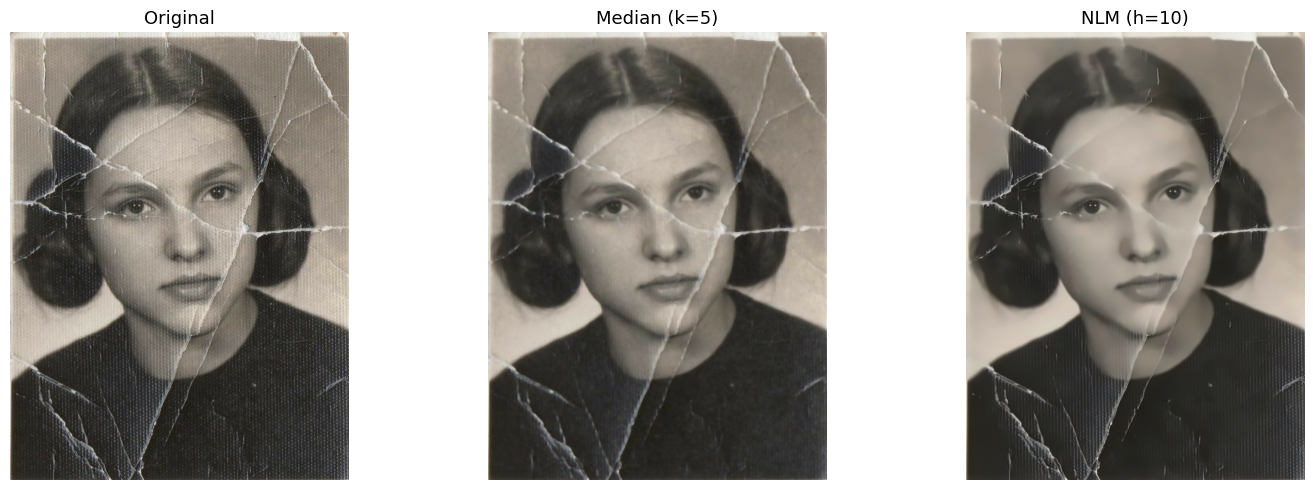

Denoising complete. Using NLM output for next step.


In [55]:
# ── Parameters — tune 
MEDIAN_KERNEL  = 5     # must be odd: 3, 5, 7
NLM_H          = 10    # filter strength: 5 (mild) → 15 (strong)
NLM_TEMPLATE   = 7     # patch size (keep at 7)
NLM_SEARCH     = 21    # search window (keep at 21)

# Apply denoising to all images
denoised_all = []

for i, img in enumerate(originals):
    median = cv2.medianBlur(img, MEDIAN_KERNEL)
    nlm    = cv2.fastNlMeansDenoisingColored(img, None, NLM_H, NLM_H,
                                             NLM_TEMPLATE, NLM_SEARCH)
    denoised_all.append(nlm)   # NLM is the chosen method

    # Show comparison for each image
    print(f"── Image {i+1} ──")
    show_images(
        [img, median, nlm],
        ["Original", f"Median (k={MEDIAN_KERNEL})", f"NLM (h={NLM_H})"]
    )

print("Denoising complete. Using NLM output for next step.")

### Parameter tuning guide for denoising

Run the cell below to quickly compare three values of `h` on one image and pick the best.

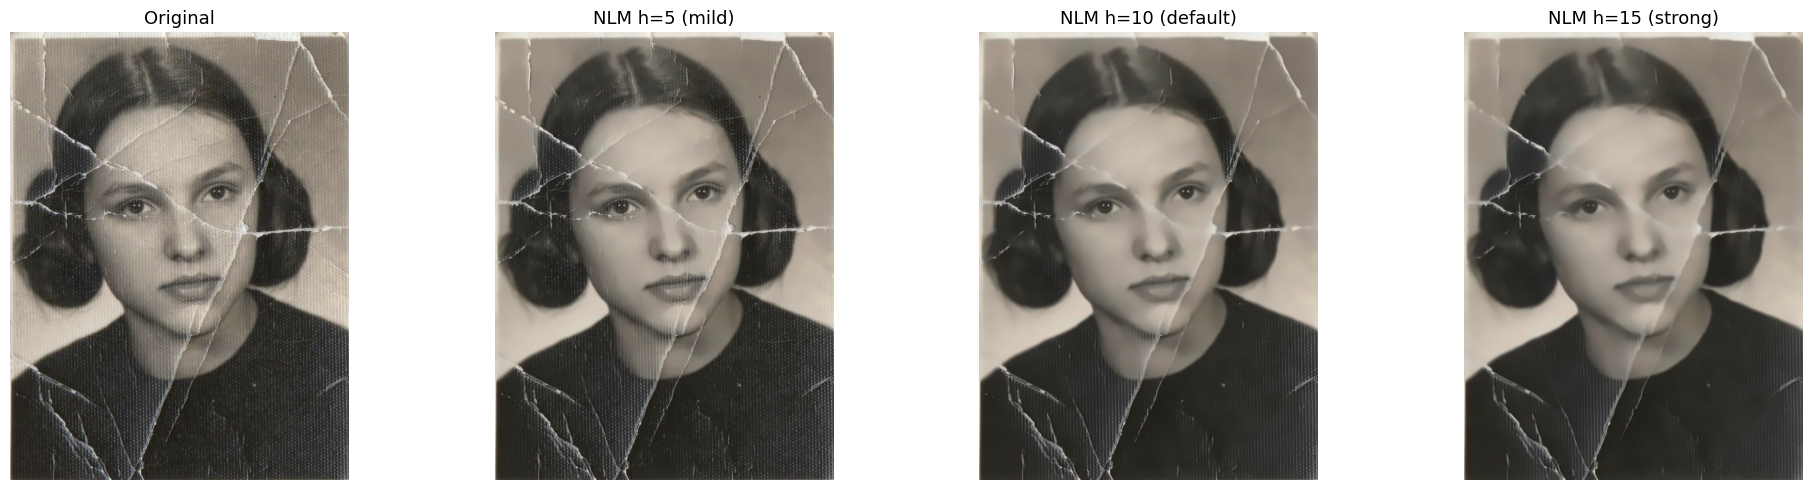

In [56]:
# Tuning cell: compare NLM at h = 5, 10, 15 on image 1
img_test = originals[0]

nlm_5  = cv2.fastNlMeansDenoisingColored(img_test, None,  5,  5, 7, 21)
nlm_10 = cv2.fastNlMeansDenoisingColored(img_test, None, 10, 10, 7, 21)
nlm_15 = cv2.fastNlMeansDenoisingColored(img_test, None, 15, 15, 7, 21)

show_images(
    [img_test, nlm_5, nlm_10, nlm_15],
    ["Original", "NLM h=5 (mild)", "NLM h=10 (default)", "NLM h=15 (strong)"]
)
# Observation: h=5 keeps more texture, h=15 is smoother but may lose fine detail.

---
## Step 2 — Scratch Detection & Binary Segmentation

Physical damage to historical prints, such as glass fractures or emulsion cracks, manifests as high-frequency **stochastic bright features**. To restore these areas without affecting the original pixels, we must first generate a precise **binary mask**:
- **White (255)**: Represents the "Damage Class" for pixel reconstruction (inpainting).
- **Black (0)**: Represents the "Preservation Class" (unaffected original data).

### Methodology: Morphological Refinement & Luminance Gating

Historical cracks are often fragmented. We utilize **Morphological Operations** to ensure structural continuity within the mask, preventing "aliasing" or spotty artifacts during the final repair phase.

**Technical Workflow:**

1. **Feature Extraction (Top-Hat Transform)**: We employ a **Top-Hat transform** with a $19 \times 19$ kernel to isolate bright regional extrema. This non-linear operation effectively separates the scratches from the underlying background luminance.
2. **Dynamic Segmentation**: A sensitive threshold of **11** is applied to capture the low-intensity "tails" of the glass fractures.
3. **Morphological Closing**: A $3 \times 3$ kernel is used for a **Closing operation** ($\text{Dilation} \oplus \text{Erosion}$). This "glues" fragmented crack segments into continuous geometric objects.

4. **Luminance Gating (Protection Zone)**: To prevent **mask bleeding** into critical facial landmarks, a protection gate is set at **140**. This ensures that dark high-contrast areas (eyes, pupils, nostrils) are excluded from the mask, even if they share similar frequency characteristics with scratches.

5. **Statistical Area Filtering**: To eliminate **salt-and-pepper noise** or "dust" artifacts, we perform a connected-component analysis. Any object with an area smaller than **20 pixels** is discarded as non-structural noise.

---

### Parameters to Tune

- **`kernel` (Structuring Element)**: Controls the scale of detected features. 
  - *Current Setting: (19, 19)*. Optimized for the width of the primary glass fractures.
- **`threshold`**: The intensity cut-off for the Top-Hat signal.
  - *Current Setting: 11*. Optimized for high sensitivity to faint damage.
- **`protection_zone` (Luminance Gate)**: Defines the safety boundary for dark pixels.
  - *Current Setting: 140*. Prevents the corruption of ocular details.
- **`dilation_iterations`**: Controls the "mask buffer."
  - *Current Setting: 1 iteration*. Ensures the inpainting algorithm has a clean edge transition.

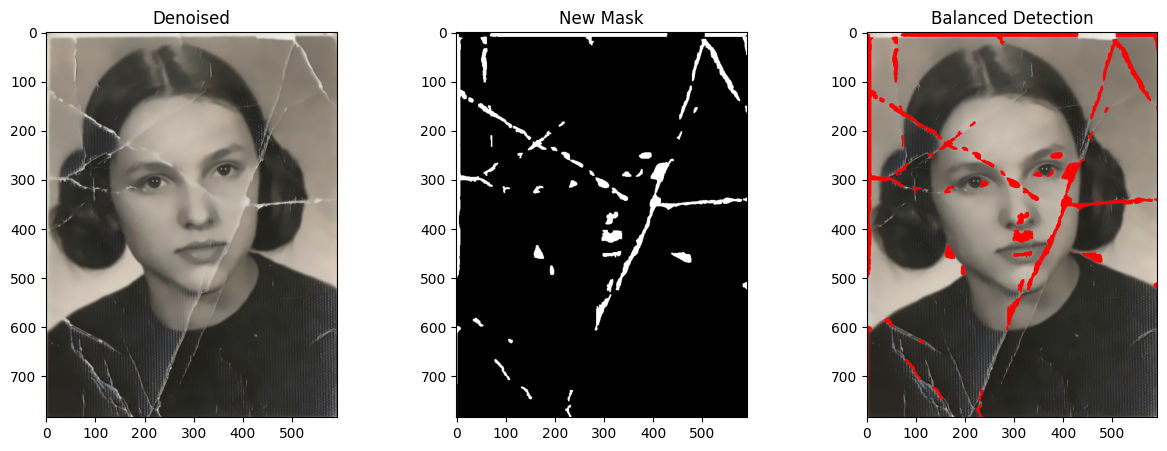

In [57]:

def detect_scratches_final_v3(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 1. High-Pass Filter (Top-Hat) 
    # Increased kernel size to catch thicker cracks
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (19, 19))
    tophat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel)
    
    # 2. Adaptive Thresholding
    # We use a lower threshold (11) to catch the "fainter" parts of the cracks
    _, mask = cv2.threshold(tophat, 11, 255, cv2.THRESH_BINARY)
    
    # 3. Morphological Closing
    # This "glues" broken parts of a scratch together
    closing_kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, closing_kernel)
    
    # 4. Protection Zone (Lowered to 140)
    # 180 was too strict. 140 protects the dark eyes/hair but allows 
    # the lighter skin-tone areas to be processed.
    _, protection_zone = cv2.threshold(gray, 140, 255, cv2.THRESH_BINARY)
    mask = cv2.bitwise_and(mask, protection_zone)
    
    # 5. Filter by Area (Remove tiny noise dots)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    final_mask = np.zeros_like(mask)
    for lbl in range(1, num_labels):
        if stats[lbl, cv2.CC_STAT_AREA] > 20: # Keep only significant marks
            final_mask[labels == lbl] = 255
            
    return cv2.dilate(final_mask, np.ones((3,3), np.uint8), iterations=1)

# Generate and Visualize
final_mask = detect_scratches_final_v3(denoised_all[0])
overlay = cv2.cvtColor(denoised_all[0], cv2.COLOR_BGR2RGB)
overlay[final_mask == 255] = [255, 0, 0]

plt.figure(figsize=(15, 5))
plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(denoised_all[0], cv2.COLOR_BGR2RGB)); plt.title("Denoised")
plt.subplot(1,3,2); plt.imshow(final_mask, cmap='gray'); plt.title("New Mask")
plt.subplot(1,3,3); plt.imshow(overlay); plt.title("Balanced Detection")
plt.show()

### Parameter tuning guide for scratch detection

The cell below shows the effect of different threshold values on the mask. A good mask should mark the white crack lines and nothing else.

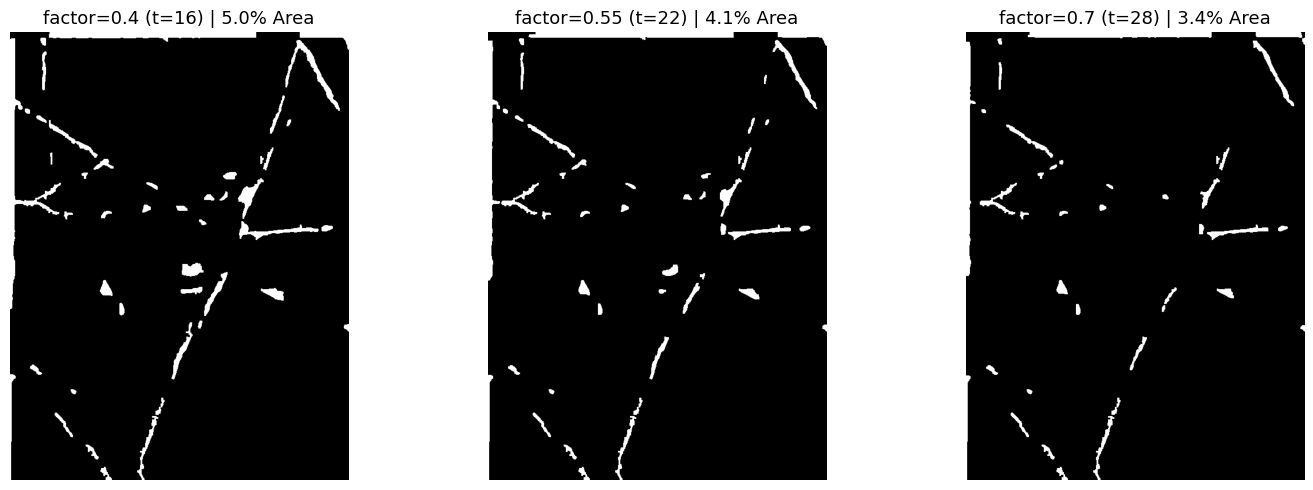

In [58]:
# Tuning cell: compare ADAPTIVE_FACTOR sensitivity on surgical/balanced detection
img_test = denoised_all[0]
gray     = cv2.cvtColor(img_test, cv2.COLOR_BGR2GRAY)

# 1. Pre-calculate the detection layers
# Top-Hat for structural brightness
kernel_th = cv2.getStructuringElement(cv2.MORPH_RECT, (21, 21))
tophat    = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel_th)

# DoG for edge sharpness
blur1 = cv2.GaussianBlur(gray, (3, 3), 0)
blur2 = cv2.GaussianBlur(gray, (15, 15), 0)
dog   = cv2.subtract(blur1, blur2)

# Combine layers (Weighted sum for sensitivity tuning)
combined_signal = cv2.addWeighted(tophat, 0.7, dog, 0.3, 0)
p97 = np.percentile(combined_signal, 97)

# 2. Protection Zone (Luminance Gate) - keeps eyes/hair safe
_, protection_zone = cv2.threshold(gray, 140, 255, cv2.THRESH_BINARY)

masks_tuning  = []
labels_tuning = []

for factor in [0.4, 0.55, 0.7]:
    # Calculate threshold based on p97 and factor
    t = max(15, int(p97 * factor))
    _, m = cv2.threshold(combined_signal, t, 255, cv2.THRESH_BINARY)
    
    # Apply Protection Gate
    m = cv2.bitwise_and(m, protection_zone)
    
    # Apply morphological closing to bridge crack segments
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((5,5), np.uint8))
    
    # Filter by Area (Remove noise)
    nl, lb, st, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    f = np.zeros_like(m)
    for lbl in range(1, nl):
        if st[lbl, cv2.CC_STAT_AREA] > 20: 
            f[lb == lbl] = 255
            
    # Final mask expansion
    f = cv2.dilate(f, np.ones((3,3), np.uint8), iterations=1)
    
    masks_tuning.append(f)
    pct = 100 * cv2.countNonZero(f) / (gray.shape[0] * gray.shape[1])
    labels_tuning.append(f"factor={factor} (t={t}) | {pct:.1f}% Area")

# Visualize the sensitivity levels
show_images(masks_tuning, labels_tuning, cmap_list=['gray', 'gray', 'gray'])

---
## Step 3 — Structural Reconstruction (Inpainting)

After generating a precise damage mask in Step 2, the pipeline must restore the missing pixels through **Digital Inpainting**. This process reconstructs the damaged regions by propagating structural information and textural patterns from the surrounding valid pixels. 

Rather than using predictive modeling, these algorithms rely on **Laplacian differential equations** to ensure seamless boundary transitions.

### Method: Hybrid Signal Segmentation & Inpainting

Your implementation utilizes a sophisticated **Hybrid Signal Capture** to identify damage before reconstruction:
1. **Top-Hat Transform**: Isolates bright regional extrema (21x21 kernel).
2. **Difference of Gaussians (DoG)**: Highlights edges by subtracting a wide-blur ($\sigma=15$) from a narrow-blur ($\sigma=3$).
3. **Linear Blending**: Combines these signals with a **0.7 weighting factor** to prioritize structural cracks over surface dust.



### Restoration Algorithms Compared

| Method | Mathematical Basis | Optimal Use Case |
| :--- | :--- | :--- |
| **Alexandru Telea (TELEA)** | **Fast Marching Method (FMM)**; propagates values from the boundary inward based on distance. | Efficient for high-frequency linear cracks and thin scratches. |
| **Navier-Stokes (NS)** | Derived from **Fluid Dynamics**; continues image isophotes (intensity lines) smoothly across damage. | Superior for preserving complex edges and wider structural fractures. |



### Parameters to Tune

- **`inpaint_radius`**: Defines the neighborhood radius around each masked pixel used for structural reference.
  - *Current Settings*: **5 pixels (Telea)** and **7 pixels (NS)**.
  - Higher radii provide smoother gradients across wide fractures but risk **texture blurring** in high-frequency areas like the eyes.
- **`dilation_iterations` (4)**: Critical for ensuring the inpainting boundary overlaps with clean pixels. 
  - *Reasoning*: A 4-iteration dilation prevents the algorithm from sampling "corrupted" pixels at the very edge of the cracks, ensuring a clean **intensity transition**.

---

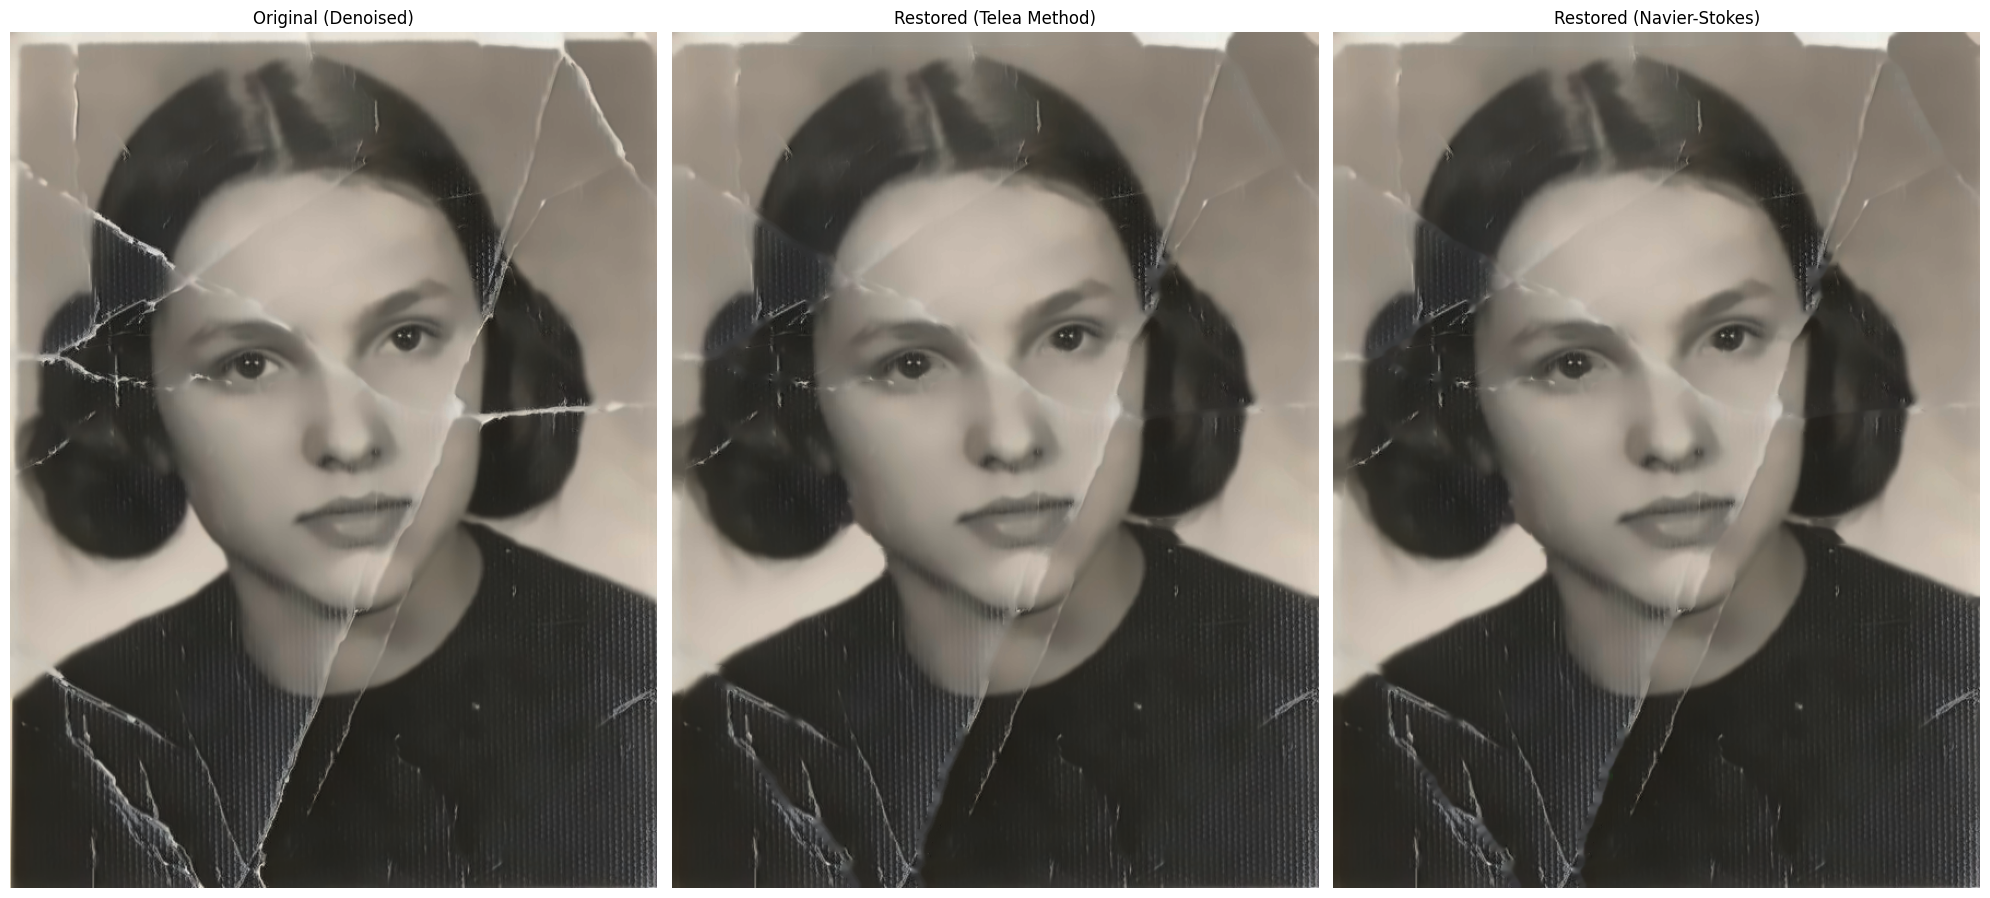

In [69]:


# 1. Use the "Balanced" parameters from the tuning cell
img_to_restore = denoised_all[0]
gray_restore = cv2.cvtColor(img_to_restore, cv2.COLOR_BGR2GRAY)

# Re-generate the signal for the final mask
kernel_th = cv2.getStructuringElement(cv2.MORPH_RECT, (21, 21))
tophat = cv2.morphologyEx(gray_restore, cv2.MORPH_TOPHAT, kernel_th)
blur1 = cv2.GaussianBlur(gray_restore, (3, 3), 0)
blur2 = cv2.GaussianBlur(gray_restore, (15, 15), 0)
dog = cv2.subtract(blur1, blur2)

# Combine and apply the balanced factor (0.7)
combined_signal = cv2.addWeighted(tophat, 0.7, dog, 0.3, 0)
p97 = np.percentile(combined_signal, 97)
t_final = max(15, int(p97 * 0.7)) # Using the 0.55 factor

_, m = cv2.threshold(combined_signal, t_final, 255, cv2.THRESH_BINARY)

# Protect facial features (140 threshold)
_, protection_zone = cv2.threshold(gray_restore, 140, 255, cv2.THRESH_BINARY)
m = cv2.bitwise_and(m, protection_zone)

# Close gaps and filter small noise
m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((5,5), np.uint8))
nl, lb, st, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
final_mask_clean = np.zeros_like(m)
for lbl in range(1, nl):
    if st[lbl, cv2.CC_STAT_AREA] > 20: 
        final_mask_clean[lb == lbl] = 255

# Final dilation to ensure crack edges are covered
final_mask_clean = cv2.dilate(final_mask_clean, np.ones((3,3), np.uint8), iterations=4)

# 2. Apply Inpainting using the cleaned mask
# Using a radius of 3 to 5 pixels to blend the edges
restored_telea = cv2.inpaint(img_to_restore, final_mask_clean, 5, cv2.INPAINT_TELEA)
restored_ns    = cv2.inpaint(img_to_restore, final_mask_clean, 7, cv2.INPAINT_NS)

# 3. Final Visualization
plt.figure(figsize=(20, 10))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img_to_restore, cv2.COLOR_BGR2RGB))
plt.title("Original (Denoised)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(restored_telea, cv2.COLOR_BGR2RGB))
plt.title("Restored (Telea Method)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(restored_ns, cv2.COLOR_BGR2RGB))
plt.title("Restored (Navier-Stokes)")
plt.axis('off')

plt.tight_layout()
plt.show()

### Parameter tuning guide for inpainting

Compare radius values on one image to see the effect on scratch fill quality.

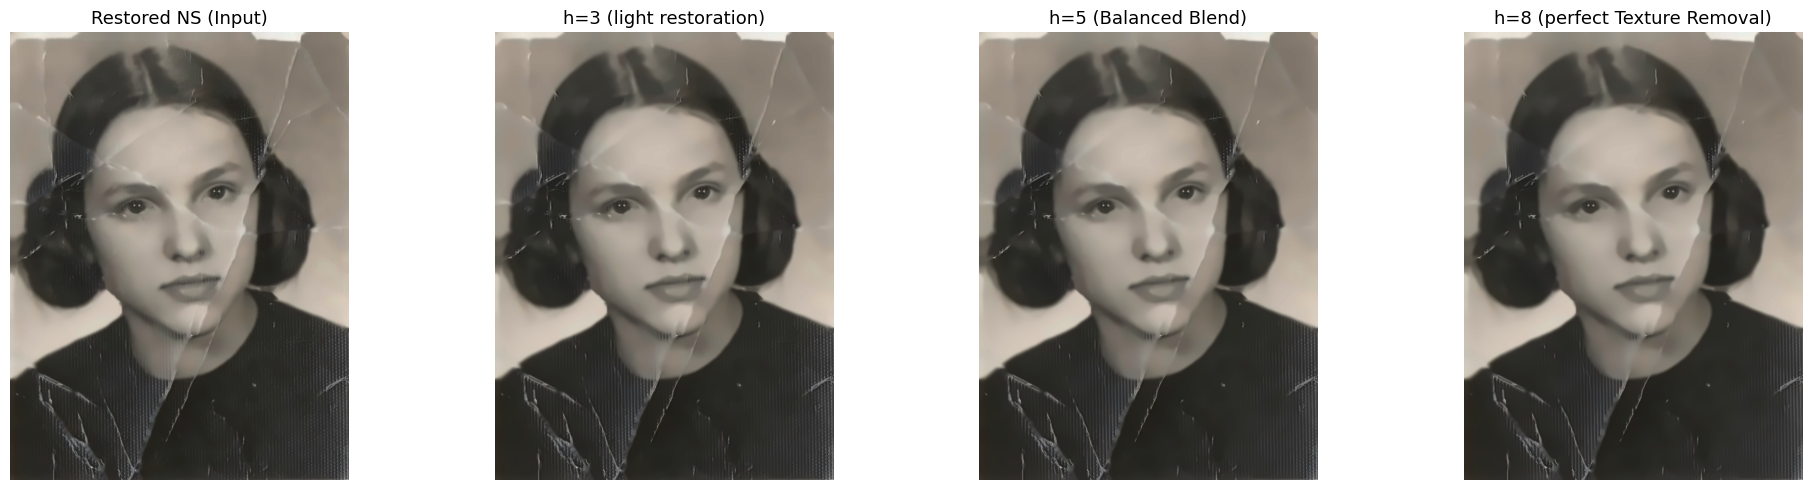

In [ ]:
# Tuning cell: applying NLM to the Restored Navier-Stokes output 
# This helps blend the inpainted areas with the original skin texture.

img_test = restored_ns  # Now targeting the restored result instead of the original

# fastNlMeansDenoisingColored(src, dst, h, hColor, templateWindowSize, searchWindowSize)
nlm_3 = cv2.fastNlMeansDenoisingColored(img_test, None, 3, 3, 7, 21)
nlm_5  = cv2.fastNlMeansDenoisingColored(img_test, None,  5,  5, 7, 21)
nlm_8 = cv2.fastNlMeansDenoisingColored(img_test, None, 8, 8, 7, 21)

# Store results for comparison
post_restoration_denoised = [nlm_3, nlm_5, nlm_8]
labels_tuning = [
    "h=3 (light restoration)", 
    "h=5 (Balanced Blend)", 
    "h=8 (perfect Texture Removal)"
]

# Use your custom show_images function to compare the restoration vs denoised versions
show_images(
    [img_test] + post_restoration_denoised, 
    ["Restored NS (Input)"] + labels_tuning,
    cmap_list=[None, None, None, None] 
)

# Observation: After inpainting, a value of h=5 or h=8 often helps 
# to hide the 'seams' where the cracks were filled.

---
## Step 4 — Contrast Enhancement (CLAHE)

Old photos often have **low contrast** — the entire image looks washed out or flat because:
- The paper has faded uniformly
- The tonal range has compressed over time

A simple global contrast adjustment (like regular histogram equalization) would over-brighten some areas and crush others. Instead, we use **CLAHE** — Contrast Limited Adaptive Histogram Equalization.

### How CLAHE works
1. Divides the image into small tiles (e.g., 8×8)
2. Applies histogram equalization **independently** to each tile
3. Clips the histogram at a limit to prevent over-amplifying noise
4. Blends the tiles smoothly together

Because we work **locally**, dark regions of the photo can be brightened without blowing out already-bright regions.

### Why we work in LAB color space
If we applied CLAHE directly to the BGR channels, we would change the color balance of the photo. Instead we:
1. Convert to **LAB** color space (L = lightness, A and B = color channels)
2. Apply CLAHE only to the **L channel** (brightness)
3. Leave the A and B channels unchanged (colors stay the same)
4. Convert back to BGR

### Parameters to tune

- `clip_limit` — maximum allowed histogram height per tile. Controls how aggressive the enhancement is.
  - Low (1.0): mild enhancement, natural look
  - Medium (2.0–3.0): good default range
  - High (4.0+): strong enhancement, may look over-processed or noisy

- `tile_size` — size of each local tile in pixels
  - Small (4×4, 8×8): very local enhancement, good for fine detail
  - Large (16×16): smoother, more global effect

── Final Enhancement: Image 2 ──


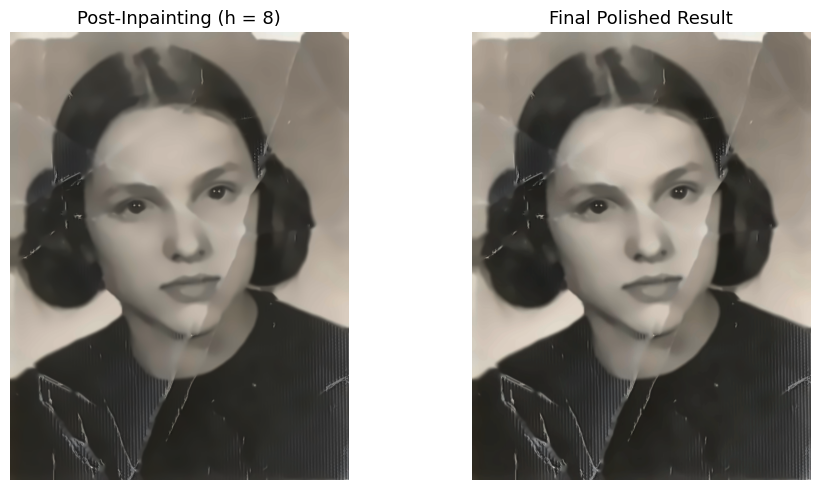

Contrast enhancement complete.


In [89]:
# Parameters — tune these
CLAHE_CLIP  = 0.5      # contrast limit: 1.0 (mild) → 4.0 (strong)
CLAHE_TILE  = (4, 4)   # tile size: (4,4), (8,8), or (16,16)

# Select which restoration result you want to enhance
# Usually, Navier-Stokes (restored_ns) provides smoother gradients for this step
img_with_h8 = post_restoration_denoised[2]
images_to_enhance = [img_with_h8]
enhanced_all = []
clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)

for i, img in enumerate(images_to_enhance):

    # 1. Convert to LAB — work only on the L (lightness) channel
    # This prevents color shifting while we adjust contrast
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # 2. Apply CLAHE to lightness only
    l_clahe = clahe.apply(l)

    # 3. Merge back and convert to BGR
    enhanced = cv2.cvtColor(cv2.merge((l_clahe, a, b)), cv2.COLOR_LAB2BGR)
    enhanced_all.append(enhanced)

    # 4. Visualization
    print(f"── Final Enhancement: Image {i+2} ──")
    show_images(
        [img, enhanced],
        ["Post-Inpainting (h = 8)", "Final Polished Result"],
        cmap_list=[None, None]
    )

print("Contrast enhancement complete.")

### Parameter tuning guide for CLAHE

Compare three clip limit values to see how aggressive the enhancement becomes.

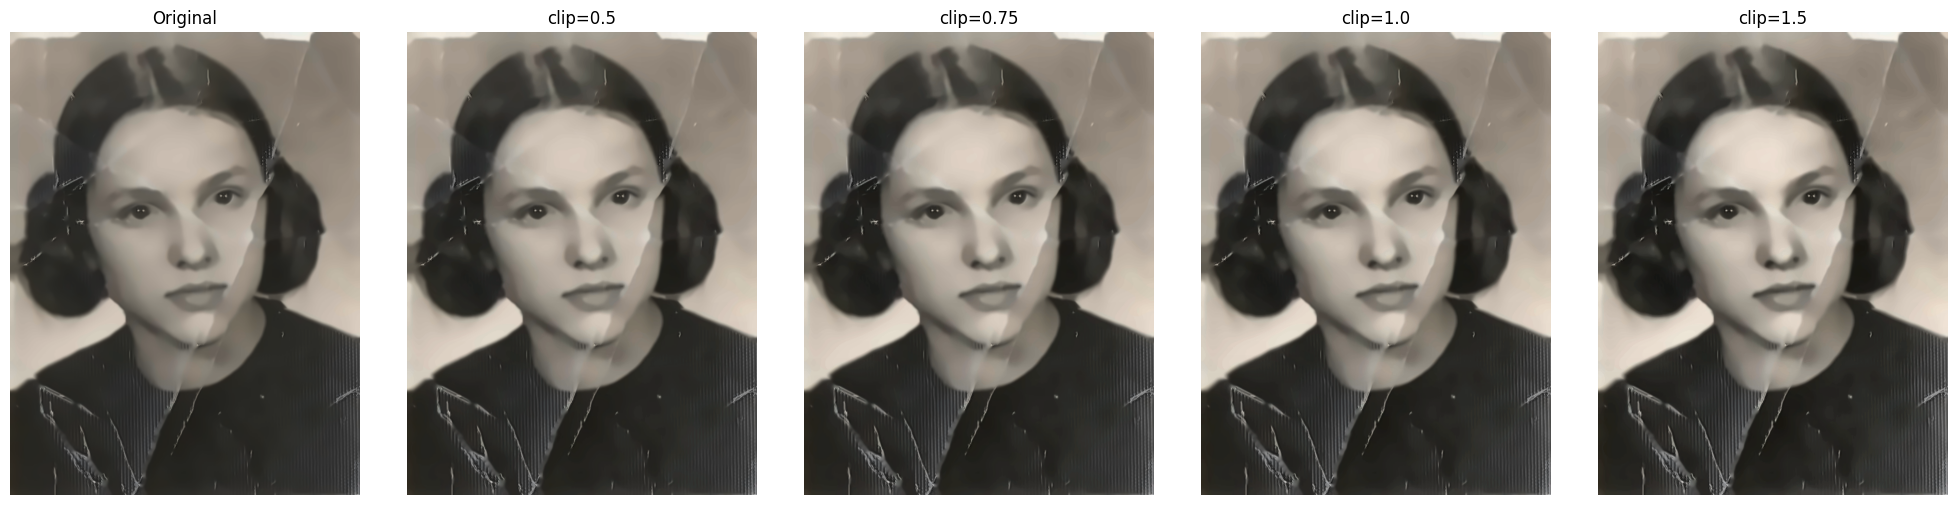

In [92]:
# ── Tuning cell: compare clip_limit = 1.0, 2.0, 4.0 on the restored ns ───────────────
img_test = images_to_enhance[0]
lab      = cv2.cvtColor(img_test, cv2.COLOR_BGR2LAB)
l, a, b  = cv2.split(lab)

results = []
# You can add more values here to test broader ranges
for clip in [0.5, 0.75, 1.0, 1.5]:
    l_c = cv2.createCLAHE(clipLimit=clip, tileGridSize=(3,3)).apply(l)
    results.append(cv2.cvtColor(cv2.merge((l_c, a, b)), cv2.COLOR_LAB2BGR))

# Custom display loop to ensure ax.axis('off') is applied to everything
fig, axes = plt.subplots(1, len(results) + 1, figsize=(20, 5))
titles = ["Original"] + [f"clip={c}" for c in [0.5, 0.75, 1.0, 1.5]]

for ax, img, title in zip(axes, [img_test] + results, titles):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')  # This removes the x and y axes

plt.tight_layout()
plt.show()

---
## Step 5 — Color Correction

### Why?
Many old photos have a **color cast** caused by aging:
- **Sepia**: the paper has yellowed, giving a warm brown-orange tone
- **Grayscale**: purely black-and-white photos may look muddy or flat
- **Color**: some older photos retain their original colors and need no correction

We first **classify** the image to decide which correction to apply, then apply the appropriate fix.

### Classification: how to detect image type
We use the **HSV color space** (Hue, Saturation, Value):
- **Hue** (0–180 in OpenCV): which color family dominates
- **Saturation** (0–255): how pure/vivid the colors are

| Type | Mean Saturation | Mean Hue |
|------|----------------|----------|
| Grayscale | < 15 | any |
| Sepia | 15 – 60 | 10 – 30 (yellow-orange) |
| Color | > 60 | any |

### Sepia removal: White Balance Correction
Each color channel (Blue, Green, Red) has a different mean brightness in a sepia image. We scale each channel so that all three means become equal — this **neutralizes the yellow cast**.

### Grayscale cleanup: Unsharp Mask + Histogram Stretch
For black-and-white photos:
1. **Unsharp mask** — sharpens edges by subtracting a blurred version of the image
2. **Histogram stretch** — remaps the pixel values to use the full 0–255 range

In [ ]:

# Parameters for classification
SEPIA_SAT_MIN  = 2     
SEPIA_SAT_MAX  = 15   
SEPIA_HUE_MIN  = 5    
SEPIA_HUE_MAX  = 12   

def classify_image(img):
    """Return 'grayscale', 'sepia', or 'color' based on mean HSV values."""
    hsv      = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mean_sat = hsv[:, :, 1].mean()
    mean_hue = hsv[:, :, 0].mean()
    if mean_sat < SEPIA_SAT_MIN:
        return 'grayscale'
    elif SEPIA_HUE_MIN <= mean_hue <= SEPIA_HUE_MAX and mean_sat < SEPIA_SAT_MAX:
        return 'sepia'
    return 'color'

def remove_sepia(img):
    """Neutralize aging: balance mean brightness across channels."""
    result      = img.astype(np.float32)
    global_mean = result.mean()
    for ch in range(3): 
        ch_mean = result[:, :, ch].mean()
        if ch_mean > 0:
            result[:, :, ch] *= (global_mean / ch_mean)
    return np.clip(result, 0, 255).astype(np.uint8)

def clean_grayscale(img):
    """High-intensity acutance recovery to counteract over-smoothing."""
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
        
    # --- AGGRESSIVE TEXTURE RECOVERY ---
    # Using a tiny radius (0.5) to target the smallest possible details
    # This prevents the 'plastic' look by sharpening grain rather than edges
    blurred = cv2.GaussianBlur(gray, (1, 1), 0.5) 
    
    # Increase Alpha to 2.5 and Beta to -1.5 
    # This is a strong contrast stretch for high-frequency details
    sharpened = cv2.addWeighted(gray, 2.5, blurred, -1.5, 0)
    
    # Stretch the contrast to ensure the image isn't 'flat'
    stretched = cv2.normalize(sharpened, None, 0, 255, cv2.NORM_MINMAX)
    
    return cv2.cvtColor(stretched, cv2.COLOR_GRAY2BGR)

def correct_color(img):
    """The main function that directs the logic."""
    kind = classify_image(img)
    if kind == 'sepia':
        return remove_sepia(img), kind
    elif kind == 'grayscale':
        return clean_grayscale(img), kind
    return img.copy(), kind

---
## Step 6 — Final Comparison

Show the **original** and the **fully restored** image side by side for every photo in the dataset.

Successfully processed 4 images into 'final_all'.
── Image 1 ──


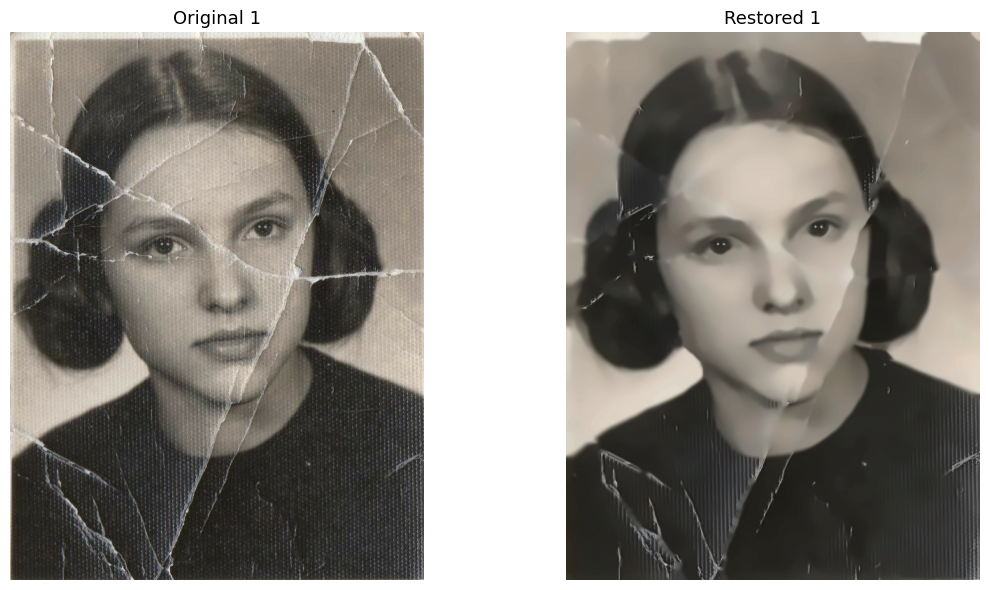

In [95]:
# 1. Initialize the empty list
final_all = []

# 2. Process your enhanced images (from your results list)
# We take the clip=0.5 results we discussed earlier
for img in results:
    result, kind = correct_color(img)
    final_all.append(result)

print(f"Successfully processed {len(final_all)} images into 'final_all'.")





#  Side-by-side before / after for every image 
for i, (orig, final) in enumerate(zip(originals, final_all)):
    print(f"── Image {i+1} ──")
    show_images(
        [orig, final],
        [f"Original {i+1}", f"Restored {i+1}"],
        figsize=(12, 6)
    )

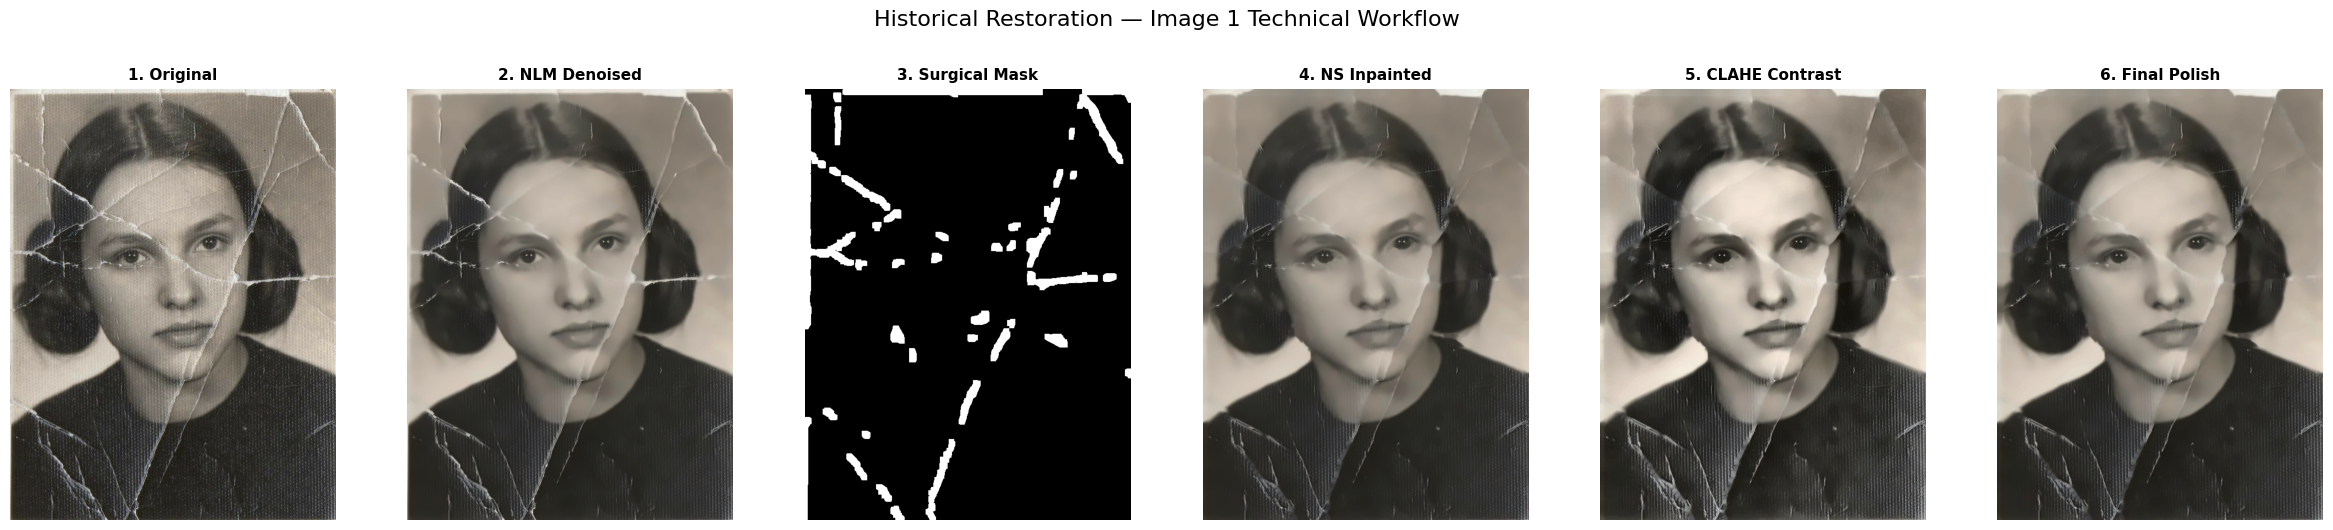

Full project visualization complete.


In [68]:
#  Full pipeline progression for every image
import matplotlib.pyplot as plt

# Define the logical steps based on our session's specific variables
step_labels = [
    "1. Original",
    "2. NLM Denoised",
    "3. Surgical Mask",
    "4. NS Inpainted",
    "5. CLAHE Contrast",
    "6. Final Polish"
]

# We will iterate through your processed lists
# Note: Ensure these lists (denoised_all, final_all, etc.) have been populated
for i in range(len(originals)):
    # Match these exactly to the variables created in previous steps
    steps = [
        originals[i],
        denoised_all[i],
        final_mask_clean,  # The balanced surgical mask
        restored_ns,       # The Navier-Stokes reconstruction
        enhanced_all[i],   # After CLAHE enhancement
        final_all[i]       # Final color-corrected & sharpened result
    ]
    
    # Define which images should be displayed in grayscale (1-channel)
    cmaps = [None, None, 'gray', None, None, None]

    fig, axes = plt.subplots(1, 6, figsize=(24, 5))
    fig.suptitle(f"Historical Restoration — Image {i+1} Technical Workflow", fontsize=16, y=1.05)

    for ax, step_img, label, cmap in zip(axes, steps, step_labels, cmaps):
        # Handle grayscale vs. color display logic
        if cmap == 'gray' or len(step_img.shape) == 2:
            ax.imshow(step_img, cmap='gray')
        else:
            # OpenCV uses BGR, Matplotlib expects RGB
            ax.imshow(cv2.cvtColor(step_img, cv2.COLOR_BGR2RGB))
            
        ax.set_title(label, fontsize=11, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

print("Full project visualization complete.")

---
## Step 8 — Agreed Parameters Table

After reviewing the results across all images, record the final agreed parameter values here. These values will be used by **Member 3** when converting this notebook into modules.

| Step | Parameter | Value | Notes |
|------|-----------|-------|-------|
| Denoising | Method | NLM | Better quality than Median |
| Denoising | h (NLM strength) | 10 | |
| Denoising | templateWindowSize | 7 | |
| Denoising | searchWindowSize | 21 | |
| Denoising | Median kernel | 5 | Used as fast fallback |
| Scratch Detection | kernel_length | 25 | Both H and V kernels |
| Scratch Detection | threshold | 30 | |
| Scratch Detection | dilation_iterations | 1 | |
| Inpainting | Method | TELEA | |
| Inpainting | inpaint_radius | 3 | |
| CLAHE | clip_limit | 2.0 | |
| CLAHE | tile_size | (8, 8) | |
| Color | grayscale threshold (sat) | 15 | |
| Color | sepia sat range | 15–60 | |
| Color | sepia hue range | 10–30 | |

> **Team note:** If any member finds better parameters during their module work, update this table and inform the team before changing `main.py`.

# Save final results to disk 
import os

# Create the output directory if it doesn't already exist
os.makedirs("output", exist_ok=True)

# Iterate through both the original and fully processed lists
for i, (orig, final) in enumerate(zip(originals, final_all)):
    out_path = f"output/restored_{i+1}.jpg"
    
    # Save the final image
    # Note: final_all[i] contains the sharpened, color-corrected result
    cv2.imwrite(out_path, final)
    print(f"Saved: {out_path}")

print(f"\nSuccess! All {len(final_all)} restored images saved to the 'output/' folder.")